In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
file_path = "Customer_Churn_Data_Large.xlsx"

df_demo = pd.read_excel(file_path, sheet_name="Customer_Demographics")
df_trans = pd.read_excel(file_path, sheet_name="Transaction_History")
df_service = pd.read_excel(file_path, sheet_name="Customer_Service")
df_online = pd.read_excel(file_path, sheet_name="Online_Activity")
df_churn = pd.read_excel(file_path, sheet_name="Churn_Status")

In [49]:
df = df_demo.merge(df_churn, on="CustomerID", how="left")

df = df.merge(df_online, on="CustomerID", how="left")

In [50]:
print(df.columns)
df.head()

Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel',
       'ChurnStatus', 'LastLoginDate', 'LoginFrequency', 'ServiceUsage'],
      dtype='object')


,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,ChurnStatus,LastLoginDate,LoginFrequency,ServiceUsage
0,1,62,M,Single,Low,0,2023-10-21,34,Mobile App
1,2,65,M,Married,Low,1,2023-12-05,5,Website
2,3,18,M,Single,Low,0,2023-11-15,3,Website
3,4,21,M,Widowed,Low,0,2023-08-25,2,Website
4,5,21,M,Divorced,Medium,0,2023-10-27,41,Website


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CustomerID      1000 non-null   int64         
 1   Age             1000 non-null   int64         
 2   Gender          1000 non-null   object        
 3   MaritalStatus   1000 non-null   object        
 4   IncomeLevel     1000 non-null   object        
 5   ChurnStatus     1000 non-null   int64         
 6   LastLoginDate   1000 non-null   datetime64[ns]
 7   LoginFrequency  1000 non-null   int64         
 8   ServiceUsage    1000 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 70.4+ KB


In [52]:
df.describe()

,CustomerID,Age,ChurnStatus,LastLoginDate,LoginFrequency
count,1000.000000,1000.000000,1000.000000,1000,1000.000000
mean,500.500000,43.267000,0.204000,2023-07-05 21:28:48,25.912000
min,1.000000,18.000000,0.000000,2023-01-01 00:00:00,1.000000
25%,250.750000,30.000000,0.000000,2023-04-08 00:00:00,13.750000
50%,500.500000,43.000000,0.000000,2023-07-10 12:00:00,27.000000
75%,750.250000,56.000000,0.000000,2023-10-01 06:00:00,38.000000
max,1000.000000,69.000000,1.000000,2023-12-31 00:00:00,49.000000
std,288.819436,15.242311,0.403171,NaN,14.055953


In [53]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.fillna(method='ffill', inplace=True)

C:\Users\sandu\AppData\Local\Temp\ipykernel_43104\1168271076.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [54]:
df.to_csv("cleaned_churn_data.csv", index=False)

In [55]:
# Style Settings (Black + Yellow + Orange Theme)

plt.style.use('dark_background')
sns.set_style("darkgrid")

plt.rcParams['figure.facecolor'] = '#000000'
plt.rcParams['axes.facecolor'] = '#000000'
plt.rcParams['savefig.facecolor'] = '#000000'

# Custom Color Palette
colors = ['#FFC300', '#FF8C00', '#FFD700']


In [ ]:
#Figure : 4.1 Target Variable Distribution

C:\Users\sandu\AppData\Local\Temp\ipykernel_43104\20486354.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


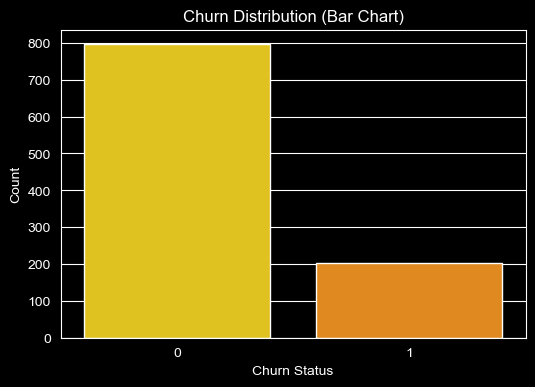

In [63]:
plt.style.use('dark_background')
plt.figure(figsize=(6,4))
sns.countplot(
    x='ChurnStatus',
    data=df,
    palette=['#FFD700', '#FF8C00']  # Yellow and Orange
)

plt.title("Churn Distribution (Bar Chart)", color='white')
plt.xlabel("Churn Status", color='white')
plt.ylabel("Count", color='white')

plt.savefig("01_Churn_Distribution_Bar_Chart.png", dpi=300,bbox_inches='tight' )
plt.show()

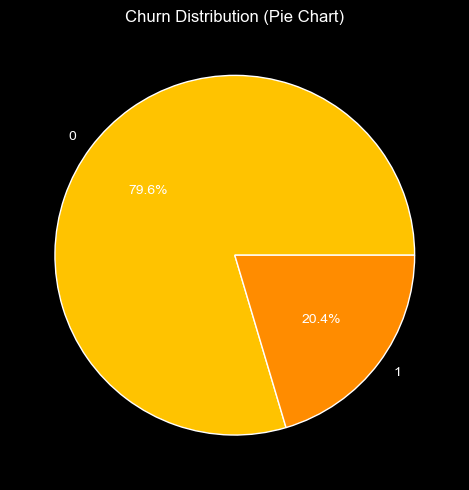

In [65]:
plt.figure(figsize=(8,5))
df['ChurnStatus'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#FFC300', '#FF8C00'],
    textprops={'color':'white'}
)
plt.title("Churn Distribution (Pie Chart)", color='white')
plt.ylabel("")
plt.tight_layout()
plt.savefig("02_Churn_Distribution_Pie_Chart.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Figure: 4.2 Gender vs Churn (Stacked Bar)

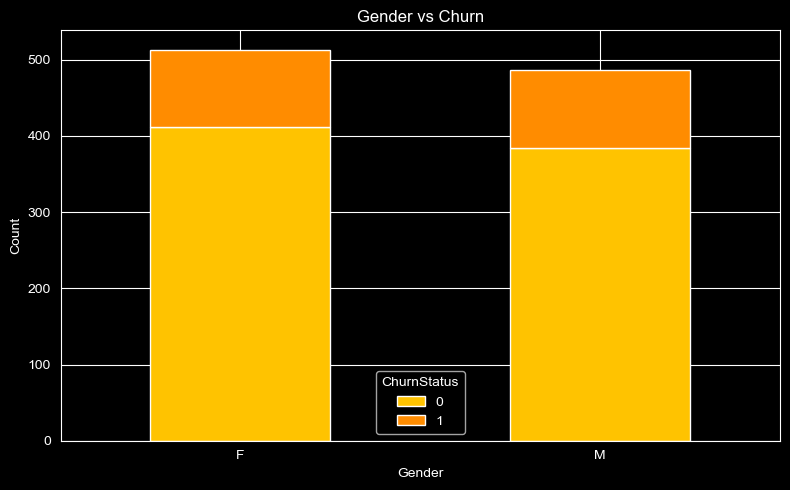

In [67]:
gender_churn = pd.crosstab(df['Gender'], df['ChurnStatus'])

gender_churn.plot(
    kind='bar',
    stacked=True,
    color=['#FFC300', '#FF8C00'],
    figsize=(8,5)
)
plt.title("Gender vs Churn", color='white')
plt.xlabel("Gender", color='white')
plt.ylabel("Count", color='white')
plt.xticks(rotation=0, color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.savefig("03_Gender_vs_Churn.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Figure: 4.3 IncomeLevel (Low, Medium, High) vs ChurnStatus

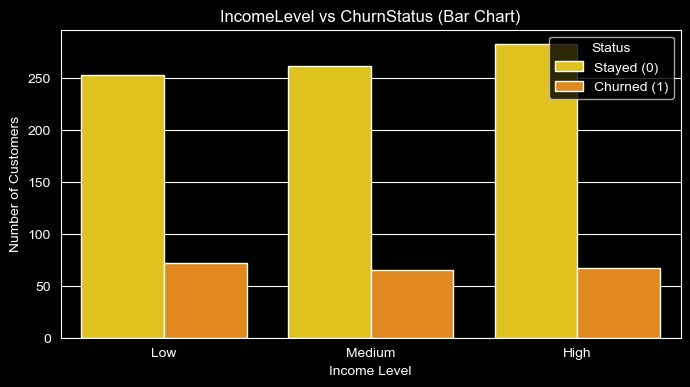

In [79]:
plt.style.use('dark_background')
plt.figure(figsize=(8,4))
sns.countplot(
    x='IncomeLevel',
    hue='ChurnStatus',         
    data=df,
    order=['Low', 'Medium', 'High'], 
    palette=['#FFD700', '#FF8C00']   # Yellow for Stayed, Orange for Churned
)

plt.title("IncomeLevel vs ChurnStatus (Bar Chart)", color='white')
plt.xlabel("Income Level", color='white')
plt.ylabel("Number of Customers", color='white')
plt.legend(title='Status', labels=['Stayed (0)', 'Churned (1)'])

plt.savefig("04_CIncomeLevel vs ChurnStatus_Bar_Chart.png", dpi=300,bbox_inches='tight' )
plt.show()

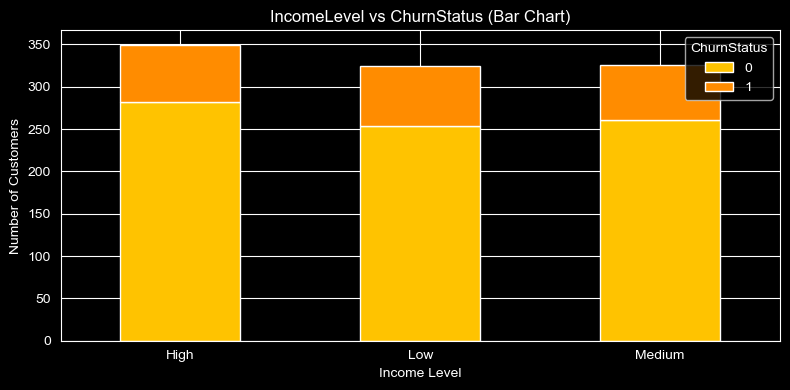

In [78]:
income_churn = pd.crosstab(df['IncomeLevel'], df['ChurnStatus'])

income_churn.plot(
    kind='bar',
    stacked=True,
    color=['#FFC300', '#FF8C00'],
    figsize=(8,4)
)
plt.title("IncomeLevel vs ChurnStatus (Bar Chart)", color='white')
plt.xlabel("Income Level", color='white')
plt.ylabel("Number of Customers", color='white')
plt.xticks(rotation=0, color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.savefig("05_CIncomeLevel vs ChurnStatus.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Figure: 4.4 Age Distribution

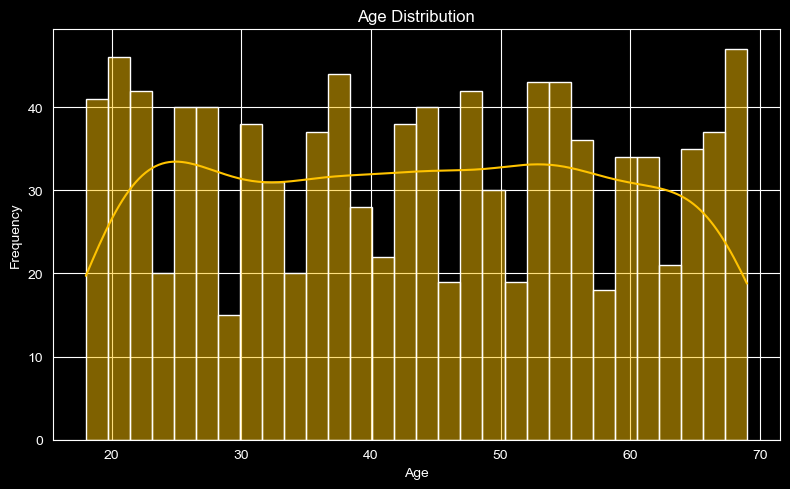

In [82]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True, color='#FFC300')
plt.title("Age Distribution", color='white')
plt.xlabel("Age", color='white')
plt.ylabel("Frequency", color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.savefig("06_Age_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Figure: 4.5 Age_vs_Churn

C:\Users\sandu\AppData\Local\Temp\ipykernel_43104\3572444192.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ChurnStatus', y='Age', data=df,


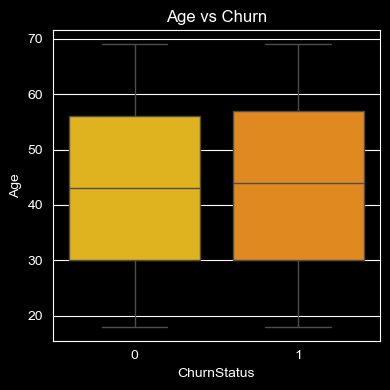

In [89]:
plt.figure(figsize=(4,4))
sns.boxplot(x='ChurnStatus', y='Age', data=df,
            palette=['#FFC300', '#FF8C00'])
plt.title("Age vs Churn", color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.savefig("07_Age_vs_Churn.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Figure: 4.6 Marital Status Analysis 

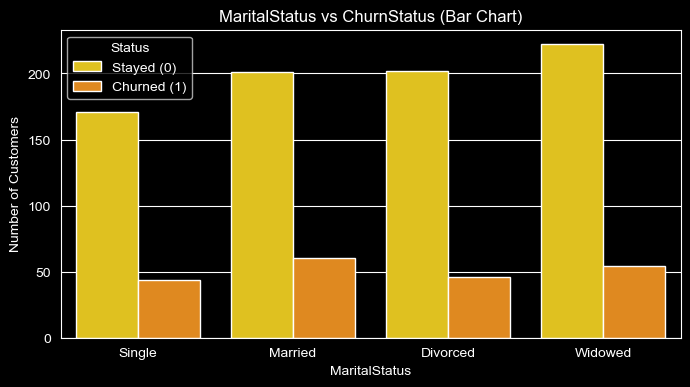

In [98]:
plt.style.use('dark_background')
plt.figure(figsize=(8,4))
sns.countplot(
    x='MaritalStatus',
    hue='ChurnStatus',         
    data=df,
    order=['Single', 'Married', 'Divorced' ,'Widowed'], 
    palette=['#FFD700', '#FF8C00']   # Yellow for Stayed, Orange for Churned
)

plt.title("MaritalStatus vs ChurnStatus (Bar Chart)", color='white')
plt.xlabel("MaritalStatus", color='white')
plt.ylabel("Number of Customers", color='white')
plt.legend(title='Status', labels=['Stayed (0)', 'Churned (1)'], loc='upper left')

plt.savefig("08_MaritalStatus vs ChurnStatus_Bar_Chart.png", dpi=300,bbox_inches='tight' )
plt.show()

In [ ]:
#Figure: 5.1 Multivariate Analysis: Income + Age vs Churn

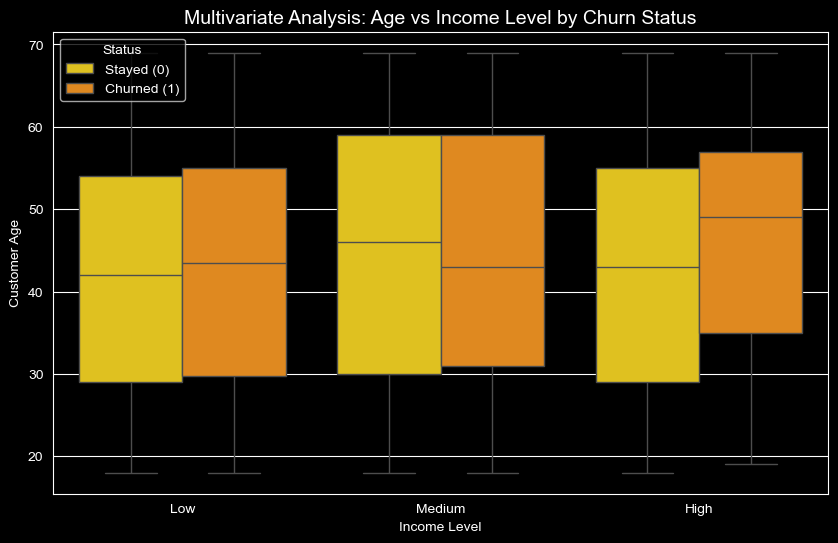

In [103]:
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

ax = sns.boxplot(
    x='IncomeLevel', 
    y='Age', 
    hue='ChurnStatus', 
    data=df, 
    order=['Low', 'Medium', 'High'],
    palette=['#FFD700', '#FF8C00'] 
)

plt.title("Multivariate Analysis: Age vs Income Level by Churn Status", color='white', fontsize=14)
plt.xlabel("Income Level", color='white')
plt.ylabel("Customer Age", color='white')

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Stayed (0)', 'Churned (1)'], title='Status', loc='upper left')

plt.savefig("09_Multivariate_Age_Income_Churn.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Figure: 5.2 Outlier Detection

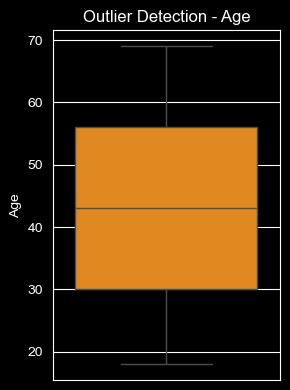

In [106]:
plt.figure(figsize=(3,4))
sns.boxplot(y=df['Age'], color='#FF8C00')
plt.title("Outlier Detection - Age", color='white')
plt.yticks(color='white')
plt.tight_layout()
plt.savefig("10_Outlier_Detection_Age.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Figure:5.3 Categorical Interactions

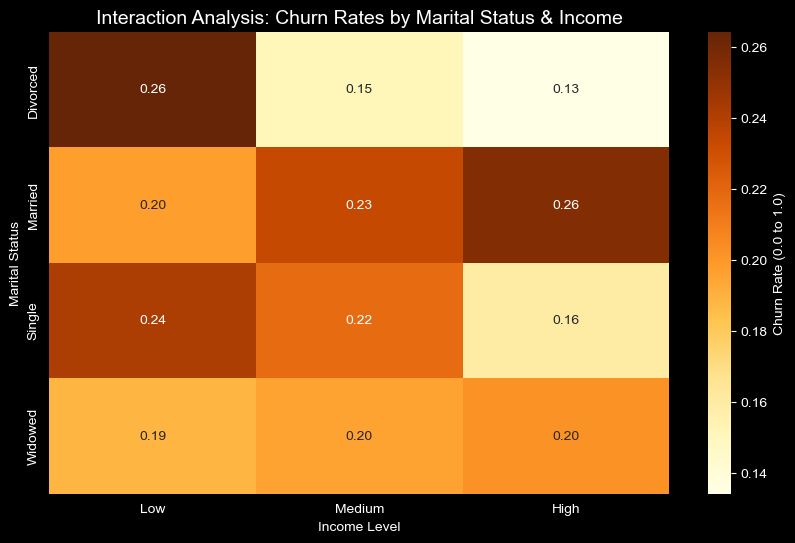

In [107]:
churn_rate_pivot = df.pivot_table(
    index='MaritalStatus', 
    columns='IncomeLevel', 
    values='ChurnStatus', 
    aggfunc='mean'
)

income_order = ['Low', 'Medium', 'High']
churn_rate_pivot = churn_rate_pivot[income_order]

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

sns.heatmap(
    churn_rate_pivot, 
    annot=True,          # Show the churn percentage values
    fmt=".2f",           # Format to 2 decimal places
    cmap='YlOrBr',       # Yellow to Orange theme
    cbar_kws={'label': 'Churn Rate (0.0 to 1.0)'}
)

plt.title("Interaction Analysis: Churn Rates by Marital Status & Income", color='white', fontsize=14)
plt.xlabel("Income Level", color='white')
plt.ylabel("Marital Status", color='white')
plt.savefig("11_3_Categorical_Interaction_Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Figure :5.4 Correlation Analysis (Heatmap)

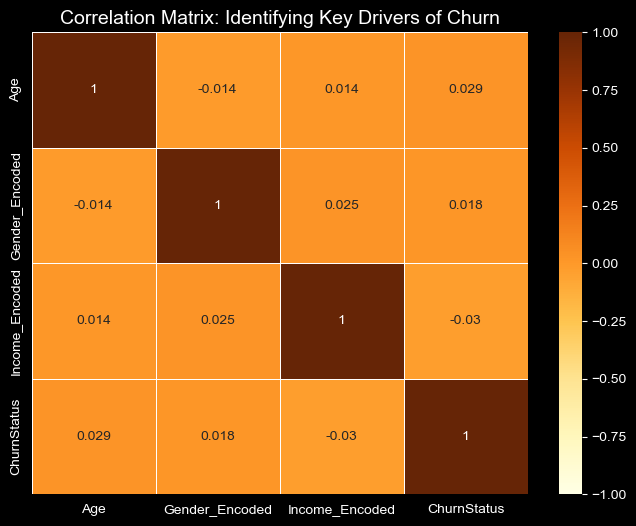

In [109]:
df_corr = df.copy()
df_corr['Gender_Encoded'] = df_corr['Gender'].map({'M': 1, 'F': 0})
df_corr['Income_Encoded'] = df_corr['IncomeLevel'].map({'Low': 0, 'Medium': 1, 'High': 2})

features = ['Age', 'Gender_Encoded', 'Income_Encoded', 'ChurnStatus']
matrix = df_corr[features].corr()


plt.style.use('dark_background')
plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix, 
    annot=True, 
    cmap='YlOrBr',       # Consistent Yellow-Orange theme
    linewidths=0.5,
    vmin=-1, vmax=1      # Standard correlation scale
)

plt.title("Correlation Matrix: Identifying Key Drivers of Churn", color='white', fontsize=14)
plt.savefig("12_4_Correlation_Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()